In [121]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import math
import random

print(torch.__version__)
print(np.__version__)
print("Ready.")

2.12.0
2.2.6
Ready.


In [122]:
def f(x):
    return 3*x**2 - 4*x + 5

In [123]:
f(3.0)

20.0

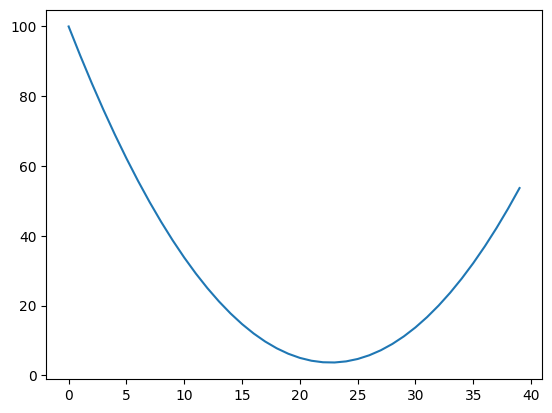

In [124]:
xs = np.arange(-5, 5, 0.25) # generates a range of -5 to 5 going up by 0.25.
ys = f(xs) # gets the y value at each point listed above
plt.plot(ys) # plots those y values

In [125]:
h = 0.00000001
x = 2/3
(f(x + h) - f(x))/h

0.0

In [126]:
#Lets get more complex now!
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [127]:
# We would liek to look at the derivative of d with respect to a,b,c and think about what it tells us. So, we are just looking at the derivative of a function with multiple inputs. Here for example we see what happens to the derivative with respect to a.
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a+=h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)
#intuitively we can tell from some quick mental math that because a is a bit more, d2 is slightly less than d1 and thus the slope is negative


d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [128]:
# Part 5: Starting the core value object of micrograd and its visualization

In [184]:
class Value: # Added comments to understand this Python clearly. This line creates a class.

    def __init__(self, value, _children=(), _op="", label=''): # As evident, Python is much like Java - it is object-oriented. Self in python is like this in java. this init funciton is like a java constructor. thE CONSTRUCTOR IS THE CODE THAT ALLOWS FOR AN OBJECT TO BE CREATED - SO IT IS WHAT RUNS WHEN YOU ATTEMPT OT CREATE AN OBJECT.
        self.value = value
        self._prev = set(_children) # created as a tuple but becomes a set for effeciency. notice that in python you can create fields dynamically - so do not need to declare _prev as a feidl in the top init line.
        self._op = _op 
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None # does not do anything by default - the case for a leaf node.
        
    # When ._prev is called, it will automatically give a set {} where the two children are formatted as according to __repr__.
# children is a pointer, and is by default an empty tuple.
    
    # Whenever an object is created, Python runs "init" to set what is IN IT!

    def __repr__(self): # This function controls how the object should appear as text.
        return f"Value(data={self.value})" # The f lets you insert variables or expressions right into the string - so your returning a strign where you inserted some variables into the string.

# This method is needed because when a class is created, this method tells Python how the object should appear as text.

    def __add__(self, other): # Must use the exact special name of __add__ and __mult__ to tell the python how operations work for this class.
        other = other if isinstance(other, Value) else Value(other) # updated add. if you can get the value of it it is other; if not it is the value itself.
        out = Value(self.value + other.value, (self, other), '+')

        def _backward(): # Let's define what our backward function should do.
            # For addition, we know it should take out's grad from above function and propagate that value to be the value of self's grad and other's grad.
            self.grad += 1.0 * out.grad # applying chain rule using 1 as local derivative of a + node.
            other.grad += 1.0 * out.grad 
            
        out._backward = _backward
        return out
        
# Note that the methods with __ in their names are called dunder methods - they run automatically in particular situations, and __add__ adn _mul__ are needed for well adding and multiplying.
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) # update multiply with same exact line.
        
        out = Value(self.value * other.value, (self, other), '*')
        return out

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

    def __rmul__(seld, other): # other * self
        return self * other # just swap order of operands!

    def __radd__(self, other):
        return self + other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.value**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * self.value**(other - 1) * other.grad # dxdL=d(out)dL*dxd(out), chain rule and AEP
        out._backward = _backward

        return out

    def __truediv__(self, other): # other * self
        return self * other**-1 # now we gotta define what it means for a value to be raised to the -1, implement the pow function.
    
# THIS IS HYPERBOLIC TAN, NOT NORMAL TAN!
    def tanh(self): # self is the value object upon which tan was called and there is no 'other' because tan needs just one input.
        x = self.value # this retreives that value objects memory - without this the object is a collection of fields but herwe we just want its value to operate on.
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1) # we use that value in the formula for tan, obtained from quick search if not memorised
        out = Value(t, (self, ), 'tanh') # the arguments match cuz t is the value, (self, ) is the child node stored as a tuple, and 'tanh' the op. Label was not provided so as per the constructor is left as ''.
        # As for self, when creating an value object such as here using =, the LS is the self implicitly provided and you do not provide it explicitly inside the Value() thing.

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward #  this is to not have None returned - _backward was defined in __init__ as none.

        return out

    # we will also define subtraction for which we will first define negation.

    def __neg__(self): # -self
        return self * -1

    def __sub__(self, other): # self- other
        return self + (-other) # note that -other is automatically translated to other.__neg__() for python! 

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp') 
        
        def _backward():
            self.grad += out.data * out.grad # out.data is already e to the power of self.value, multiply it by out.grad for the chain rule. remember 'ACCOUNTED ERASING PRINCIPLE', or 'AEP'. 
        out._backward = _backward
               
        return out
        # Now keep in mind just as we defined tan here to use in neural net you can use any function arbitrarily complex, AS LONG AS YOU ARE ABLE TO KNOW ITS DERIVATIVE FOR THE GRADIENT.

# So we now know whenever we call an arithmetic method the value, the children, and the operation.

# OUR BACKPROPAGATION FUNCTION! WOOHOO
    def backward(self):
    
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
    
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
        





a = Value(2.0, label = 'a') # Doing this declares a for example a Value object and the Value functions (methods really) apply to it.
b = Value(-3.0, label = 'b') # So this would run the "constructor" and create an object "b" of class Valye and do b.value = -3.0. self refers to b and the number inside value is value.
c = Value(10.0, label = 'c')
e = a*b; e.label = 'e'
d  = e+c; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f; L.label = 'L'


# This is roughly equivalent to (a.__mult__(b)).__add__(c) because when doing arithmetic inside a class python always tries calling __add_ and __mult__ and does whatever you defined these operations to be.
# Note that d is the child here - the Value object created using the new value objects.

# imp: So all this was just creating a class, defining the objects in it, how they will be represented, how arithmetic work son them - and whenever we used arithmetic we wanted to know the value, children and operation that created that value. 

In [130]:
# The above, as explained in the imp note, allows us to take large complex mathematical expressions and break them down so that e understand its elementary parts and can visualize them in a forward pass.

In [131]:
# Back propagation is starting at the end of the forward pass and reverse and calculate the gradient along all the intermediate values, computing the derivative of the end node with respect to all the nodes that come before it. 

In [132]:
%pip install graphviz


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [133]:
from graphviz import Digraph


def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)

            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root, format="svg", rankdir="LR"):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom) | LR (left to right)
    """

    assert rankdir in ["LR", "TB"]

    nodes, edges = trace(root)

    dot = Digraph(
        format=format,
        graph_attr={"rankdir": rankdir}
    )

    # Create the value and operation nodes
    for n in nodes:
        dot.node(
            name=str(id(n)),
            label="{ %s | data %.4f | grad %.4f }"
                  % (n.label, n.value, n.grad),
            shape="record"
        )

        if n._op:
            dot.node(
                name=str(id(n)) + n._op,
                label=n._op
            )

            dot.edge(
                str(id(n)) + n._op,
                str(id(n))
            )

    # Connect each input value to the operation that uses it
    for n1, n2 in edges:
        dot.edge(
            str(id(n1)),
            str(id(n2)) + n2._op
        )

    return dot

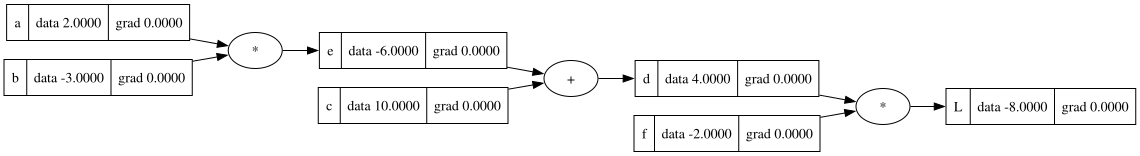

In [134]:
draw_dot(L)

In [135]:
# Part 6: Manual back propogation example 1: simple example.  these are inputted after calculations below.

L.grad = 1.0 
f.grad = d.value
d.grad = f.value
c.grad = d.grad
e.grad = d.grad
a.grad = 6.0
b.grad = -4.0

In [136]:
# Derivative of L with respect to d? Well we have L = d*f, so here we treat f as a constant and d is what we really treat as a 'real' input. This is partial derivatives calculus.

#[F(x+h) - F(x)]/h
#-> [(d+h)f - df]/h   , add h to the input being changed and treat f as a constant.
#-> [df + hf - df]/h
#-> hf/h
#-> f                 , thus the derivative is f.

# symmetrically dL/df = d.


In [137]:
# Now to derive the derivative of L with respect c - for which you first need derivative of d with respect to c.

# dd / dc = ?

# we know d = c + e...
# -> [f(x+h) - f(x)]/h
# -> [((c + h) + e) - (c + e)] / h   , c is the input we are slightly changing so we add h to it.
# -> (c + h + e - c - e)/h
# -> h/h = 1.0                       , by symmetry we also have dd/de = 1.0

# A local plus node derivative is always 1.0 as a rule.

# Great! Now we use: CHAIN RULE.
# Have: dL/dd = -2.0 and dd/dc = 1.0, want dL/dc. So, do dL/dd * dd/dc = -2.0 * 1.0 = -2.0. Notice that dL/dd * dd/dc = dL/dc, so dL/dc = -2.0.

#SO, a plus node just routes the gradient of the parent node back to the current node because when you apply chain rule the plus nodes derivative is 1.0 so the derivative of the node ahead is just routed back. 

In [138]:
# dL/da = (dL/de) * (de/da) - we already hae dL/de = -2.0 from before.
# e = a*b
# de/da = b - can confirm with mental math. Here, the value of b is -3.0.
# Thus, dL/da = (-2.0) * (-3.0) = 6.0
# Similarly dL/db = (-2.0) * (2.0) = -4.0. We got this by doing: dL/db = dL/de * de/db. 

In [139]:
# remember, in Python variables are local!

def lol():

    h = 0.0001
        
    a = Value(2.0, label = 'a') 
    b = Value(-3.0, label = 'b') 
    c = Value(10.0, label = 'c')
    e = a*b; e.label = 'e'
    d  = e+c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L1 = L.value # L1 is first calculation - the "real" unadjusted one, the second will be adjusted for "derivative with respect to ___"

          
    a = Value(2.0, label = 'a') # Getting derivative of L with respect to a.
    b = Value(-3.0, label = 'b') 
    c = Value(10.0, label = 'c')
    e = a*b; e.label = 'e'
    d  = e+c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L' #L now points to the newly calculated point - store it in L2 below!
    L2 = L.value + h # L2 = L would set the pointer L2 to the same value that L points to when in fact we just want to store L2's value in L so we say this instead.
    
    print((L2 - L1)/h)

lol()

0.9999999999976694


In [140]:
# So after understanding this simple maual example, whats an explanation for what back propogation is?
# In backpropogation, you iterate through all nodes one by one and locally apply the chain rule. We recursively apply on the chain rule backwards and get the gradient for each node.

In [141]:
# Part 7: preview of a single optimization setup


# So to adjust L, you move each individual node's value in the direction indicated by that leaf nodes gradient. For example, if I wanted to increase the value of L, I would change the 'leaf nodes' (those whose values I determine and that are not the output of a calculation; here, they are the startings a and b, then c and f) to have values closer to their gradient.
# 1. Create original graph
a = Value(2.0, label="a")
b = Value(-3.0, label="b")
c = Value(10.0, label="c")
e = a * b
d = e + c
f = Value(-2.0, label="f")
L = d * f

# 2. Manually assign gradients
L.grad = 1.0
d.grad = -2.0
f.grad = 4.0
e.grad = -2.0
c.grad = -2.0
a.grad = 6.0
b.grad = -4.0

# 3. Update only the leaves
a.value += 0.01 * a.grad
b.value += 0.01 * b.grad
c.value += 0.01 * c.grad
f.value += 0.01 * f.grad

# 4. Recalculate output
e = a * b
d = e + c
L = d * f

print(L.value)  # -7.286496

-7.286496


([<matplotlib.lines.Line2D at 0x124d69690>],
 <function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>)

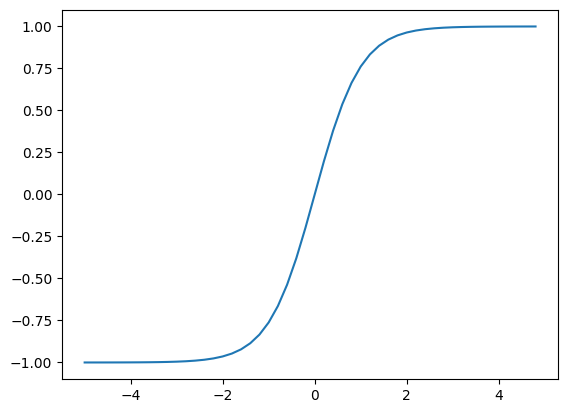

In [142]:
# Part 8: Manual back-propagation example 2: a neuron - we back propagate through them!

#np is used to do mathematical calculations on whole entire arrays.plt, by mat plot lib, lets you plot graphs. 

plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))), plt.plot
# plt.plot(x,y) plots the x and y pair - but here because we used np.arange it creates an array on each side with notation (start, stop, step), and plt.plot plots it out so you see it.

# As you will notice, in the basic mathematical structure of a neuron, we will use tan(h) as the squashing function so that big positive or really small negative numbers are nicely bound by 1 and -1. 


In [143]:
# inputs x1, x2
x1 = Value(2.0, label="x1")
x2 = Value(0.0, label="x2")

# weights w1, w2
w1 = Value(-3.0, label="w1")
w2 = Value(1.0, label="w2")

# bias of the neuron
b = Value(6.88137358701955432, label="b")

# x1*w1 + x2*w2 + b. 
x1w1 = x1 * w1
x1w1.label = "x1*w1"

x2w2 = x2 * w2
x2w2.label = "x2*w2"

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = "x1*w1 + x2*w2"

n = x1w1x2w2 + b # basically we use the dot product wherewe have (x1, x2, ..) and (w1, w2, ...) and then add b to it. thats what the calculations are doing.
n.label = "n"

o = n.tanh()
o.label = "o"


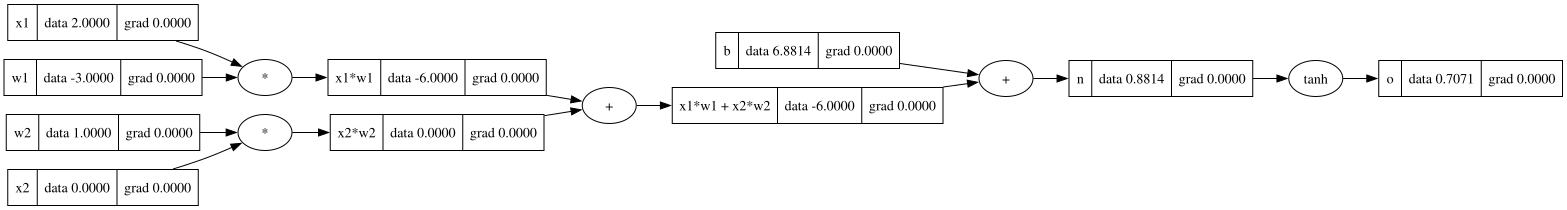

In [144]:
draw_dot(o)

In [145]:
o.grad = 1.0 # base case, always 1.0.
# Now to find the the derivative of o with respect to n.
# We know o = tanh(n), and want do/dn, and know derivative of tanh is 1 - tanh(x)^2.
# thus, do/dn = 1 - tanh(x)^2 = 1 - tanh(n)^2 = 1 - o^2.
n.grad = 1 - o.value**2

# Next we want the gradient of the two plus sign of the nodes left of the one we just got - and since those are a plus those are just a 'bridge' for the gradient to pass backwards.
x1w1x2w2.grad = 0.5
b.grad = 0.5

x1w1.grad = 0.5
x2w2.grad = 0.5

# Now for the gradient of the left-most nodes, we simply use the following trick: each noes gradient is the sibling nodes value multiplied by the gradient of the child (right-er) node.

w1.grad = x1.value * x1w1.grad
x1.grad = w1.value * x1w1.grad

x2.grad = w2.value * x2w2.grad
w2.grad = x2.value * x2w2.grad

# And ALWAYS REMEMBER: the derivative, or gradient, is what we call the mechanism that affects the output. 



In [146]:
# Part 9: We can manually backpropagate through neurons in a neural network. But can we implement this more automatically? Time to codify what was shown in examples.
# FIRST: AN IMPORTANT REVIEW!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


# Review: A gradient tells you how sensitive the final output of a neural net is in response to a particular value in the neural net. 
# We calculate the gradient using the derivative; for a node n we do: n.grad = do/dn, where o is always the final output. (Derivative of o with respect to n)
# That above calculation tells us: If the value of n changes by a tiny amount, by how much and in which direction will this drive the value of o?


# As a quick demonstration, consider o and n from the neural net right above in part 8. 
# Δo ≈ n.grad * Δn = (0.500)(0.01) = 0.005, so when the tiny change in n's value is 0.01 then the change in the value of o will be 0.005.

# For any node x in a full neural network, we have x.grad = dL/dx. 
# Now we examined n and o, which are adjacent nodes - but what if there was a random node x somewhere in the middle of the neural net?
# You would just keep using the chain rule - startign with the output and moving backwards gettign the derivative each time until you reach your desired node.
# For example, lets say the order of the nodes is x -> y -> n -> L. 
# Then, dL/dn * dn/dy * dy/dx = dL/dx. So, that's how the chain rule works and why it is important in neural nets.

# Notice that, for example, to get from n to o above, we have to apply tanh to n's value to get o, which is why o = tanh(n). 

# For addition, the local derivative is 1 because if you have for example o = x + y, then Δo/Δx = 1 - whatever x goes up or down by, so does o.
# For multiplication, the local derivative of something like o = x*y with respect to x is y and with respect to y is x. For a proof, see below:
# Consider o = x*y and then you, WLOG, add a tiny amount h to x. o = (x+h)y = xy + hy = o + hy, so do/dx = (lim h->0) Δo/Δx = (lim h->0) hy/h = (lim h->0) y = y.
# THUS, a multiplication nodes value is the incoming gradient multiplied by the value of the other node and vice versa.

# So that is why putting it all together in the neural net example above, we are just simply able to quickly determine the value using a calculation for the n's gradient but just using + and * tricks after that, starting from o and working backwards. (BACKPROPOGATING)


In [147]:
# Now let's implement the backward function for each operation - doing it manually like up until now is ridiculous. 

# We have now added _backwars to __init__ and add adn multiply and tanh.

# So, we could now calculate the gradient of the above neural net by doing duplicating the neural net and using our functions on it.
# Just need to make sure you move from RIGHT to LEFT as to get them in the right order and backpropogate:

# o.grad = 1.0 (set base case yourself)
# o._backwards()
# n._backward()
# b._backward(), and so on.

In [148]:


o.grad = 1.0

topo = [] # stores all nodes in a safe order
visited = set() # keeps track of which ones have already been visited
def build_topo(v): # this funciton receives a node and explores everythign that was used to make it.
    if v not in visited: # process node only if not already processed
        visited.add(v) 
        for child in v._prev: # keep visiting all children recursively and adding them to visited if not visited. running out of child nodes (reaching a leaf node) returns NULL which ends the for loop btw.
            build_topo(child)
    topo.append(v) # once it hits either a leaf node or a node whose children are already visited, it adds it to topo - ensuring topological ordering - meaning that values get added in order of dependancy.
    # the values get added left to right, where the nodes that give the next result are added first and the depending node afterwards.
    
build_topo(o) # using that to build the topological ordering of o's neural net.

for node in reversed(topo): # but we need to BACKPROPAGATE, so we reverse the topological ordering - so reverse that list called topo.
    node._backward() # the backwards function we built above. Now we can actually use it to get the gradient of the node that came before the node being inspected.
    # for e.g, o._backward would give n's gradient, n._backward would give b's gradient (and its siblings too) and so on.

# SOOOOO we built _backward() for backpropogating a specific node, built build_topo to get the right order so we can reverse it and apply _backward() to each node in the list and BACKPROPOGATE.
# Now we will put all this into a single function up in the 'main' cell that is important to understand. 

# Now to get the gradients of the nerual network above all we gotta do is: o.backward()


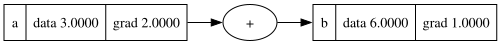

In [149]:
# Part 10: To fix a bug. Consider:

a = Value(3.0, label = 'a')
b = a + a ; b.label = 'b'
b.backward()
draw_dot(b)

In [150]:
# We can see that if we do this simple neural net where b = a + a, derivative of b should be 2 but it is not. We see an issue whenever a variable is used mroe than once.
# As the backpropogation function is running, it goes over a twice (treating it as 'two' child nodes, as it should) but it writes 1 then writes 1 again instead of adding them to 2.
# fix it by simply doing += to accumulate gradients when one variable is used more than once.
# After fixing it we get the correct gradient of 2.

In [151]:
# Part 11: Updating add. We can do a = Value(2) but not a + 1 because it thinks 1 is other and 1.value is an error.
# So we update add.
# Similarly now update multiply. That takes care of a * 2 but now to take care of 2 * a by redefining __rmul__.
# when pythin cannot multiply 2 * a it uses __rmul__ to check if it can multiply a * 2 which is rmul.

# Now we are going to go add an exponentiation function.

# Now that we have done all that, we could break tanh up into its formual involving e but that, to the overall neural net, changes nothing! Stomic or macro, its all the same.


In [152]:
# Part 12: Learn about PyTorch!

# It is a production-level deep neural network library. 
# We will learn to do the exact same thing as above using API calls. 
# What we built here from scratch - Micrograd - is scalar whereas PyTorch is not - it has tensors.


import torch

# Inputs
x1 = torch.tensor([2.0], dtype=torch.float64, requires_grad=True)
x2 = torch.tensor([0.0], dtype=torch.float64, requires_grad=True)

# Weights
w1 = torch.tensor([-3.0], dtype=torch.float64, requires_grad=True)
w2 = torch.tensor([1.0], dtype=torch.float64, requires_grad=True)

# Bias
b = torch.tensor(
    [6.8813735870195432],
    dtype=torch.float64,
    requires_grad=True
)

# Forward pass
n = x1 * w1 + x2 * w2 + b
o = torch.tanh(n)

print("output:", o.item())

# Backpropagation
o.backward()

print("x1 gradient:", x1.grad.item())
print("x2 gradient:", x2.grad.item())
print("w1 gradient:", w1.grad.item())
print("w2 gradient:", w2.grad.item())
print("bias gradient:", b.grad.item())

output: 0.7071067811865476
x1 gradient: -1.4999999999999998
x2 gradient: 0.49999999999999994
w1 gradient: 0.9999999999999999
w2 gradient: 0.0
bias gradient: 0.49999999999999994


In [153]:
torch.Tensor([2.0]).double().dtype

torch.float64

In [154]:
# Reminder: a neural net is just a specific class of mathematical expressions!

In [200]:
# Part 13: Building out a neural net library.

# First: create a class neuron that subscripes to the way that PyTorch API neurons work.

# We have already created a Value class that can store numbers, perform arithmetic, remember the alculation graph and calculat egraident usign .backward().
# Now, we will use those Value obkects to construct: Value -> Neuron -> Layer -> Neural Network


class Neuron:

    def __init__(self, nin):  # This is the neuron constructor. Self is new neuron being created and nin is the number of inputs.
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)] # For each input in the Neuron, set a random weight in range -1 to 1 and wrapi t as a Value object so you can calculate the gradient using .bacwkwards() later.
        self.b = Value(random.uniform(-1, 1)) # Creates a bias for the neuron - w1x1 + w2x2 + ... + wnxn + b, so while there are multiple weights for a neuron (one for each input) there is only one bias.

    def __call__(self, x): # This method allows you to use a neuron like a function, and __Call__ in Python is for things like n(x).
        # w*x+ba
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b) # This first zips up the weights and inputs meaning it creates tuples of each weight with its corresponding input and then multiplies each pair together, then adds them all up alongside the bias.
        out = act.tanh() # this passes the above result through the tanh activiation function. 
        return out # Sends back the final Value object.

    def parameters(self):
        return self.w + [self.b] # concatenating - this will return a list.

class Layer: # A layer is a collection of neurons.

    def __init__(self, nin, nout): # Layer constuctor. nout is the number of neurons a.k.a number of outputs.
        self.neurons = [Neuron(nin) for _ in range(nout)] # create how many number of neurons you need where nin is number of inputs given to each neuron.

    def __call__(self, x): # lets you call a layer like a function. x is the list of inputs being sent into the etire layer.
        outs = [n(x) for n in self.neurons] # This loops through each neuron in the input and calls them all with the same number of inputs.
        return outs[0] if len(outs) == 1 else outs # cannot do return outs alone - if a list hs only one valeu we just want that returned. Important because draw_dot expects one Value node not a list.

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

        
class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range (len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

#x = [2.0, 3.0]
#n = Neuron(2) # A neuron that expects 2 inputs.
# n(x)
    

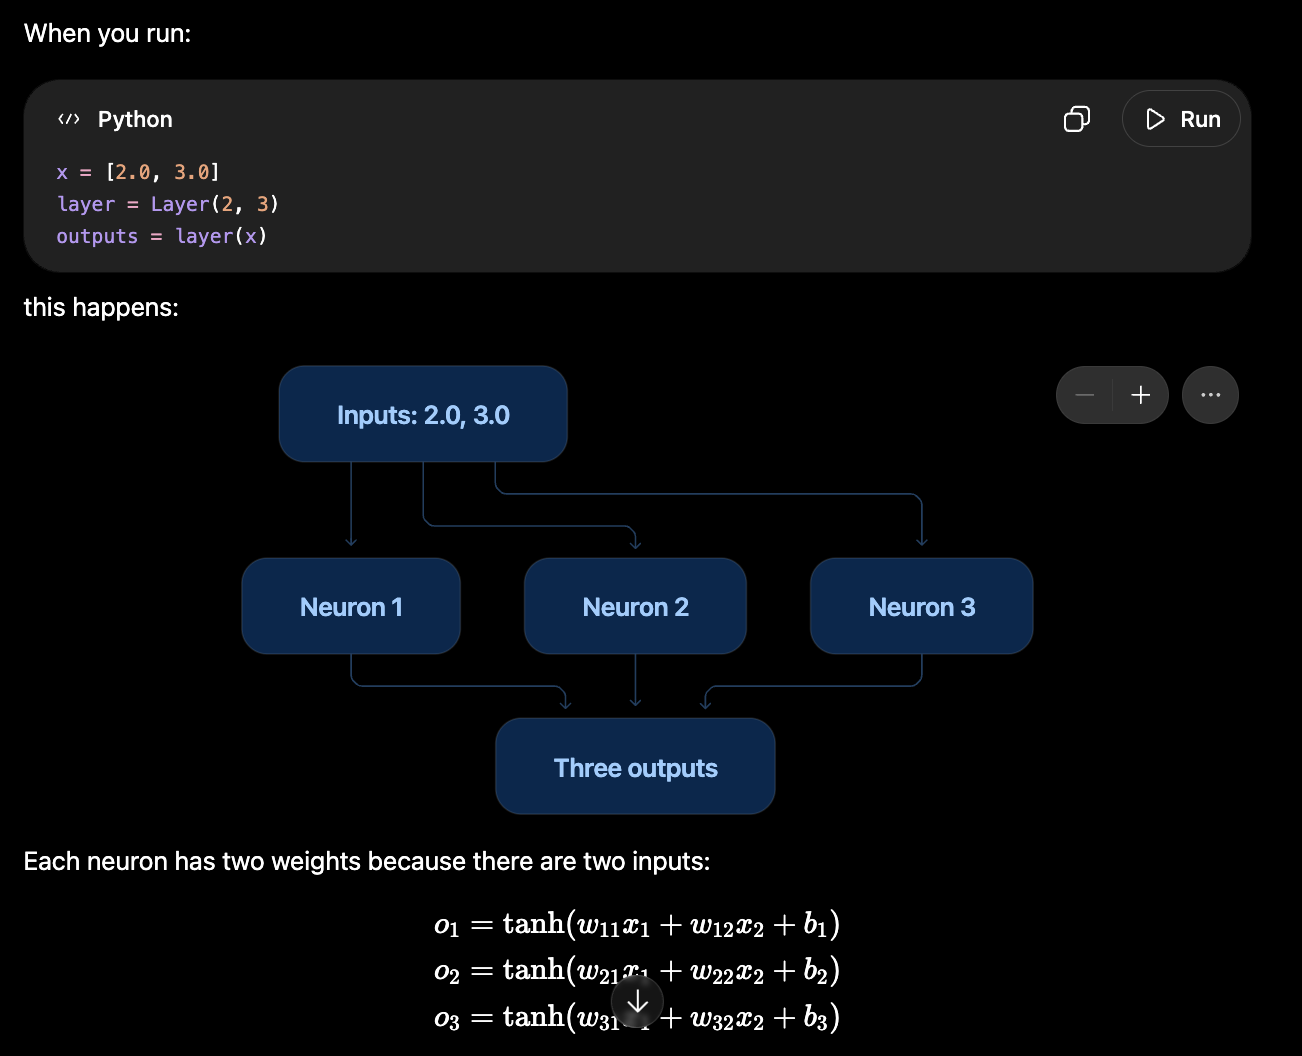

# Nice visualization above

In [156]:
# Time to complete the picture and define an entire Multi Layer Perceptron - or MLP!

# We take number of inputs samea s before but instead of a single nout (number of neurons in a single layer) we take a list of nouts which is the sizes of all the layers we want in our MLP.

In [201]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)


Value(data=0.3604757908185779)

In [204]:
n.parameters()

[Value(data=0.7040203611121745),
 Value(data=0.8265236796366517),
 Value(data=0.5316452979319486),
 Value(data=-0.8456966730825453),
 Value(data=0.28706526841726787),
 Value(data=-0.916589387702357),
 Value(data=0.47339598057795285),
 Value(data=-0.7251356321705746),
 Value(data=0.38148006769159726),
 Value(data=0.7379316333904886),
 Value(data=0.5372850711085391),
 Value(data=0.7949068784946589),
 Value(data=-0.4294410110721565),
 Value(data=0.3106912245594342),
 Value(data=0.710801110333896),
 Value(data=-0.5210012486876272),
 Value(data=0.6335935428799204),
 Value(data=-0.718891960863774),
 Value(data=0.6296038418660947),
 Value(data=0.6907341761208763),
 Value(data=-0.604667555407205),
 Value(data=-0.75674316353156),
 Value(data=-0.07510783065031723),
 Value(data=0.371303054938138),
 Value(data=0.4787270326478481),
 Value(data=0.0704534889393087),
 Value(data=-0.4674671132908923),
 Value(data=-0.8482868998329984),
 Value(data=0.920643762807674),
 Value(data=0.49544832835775954),
 V

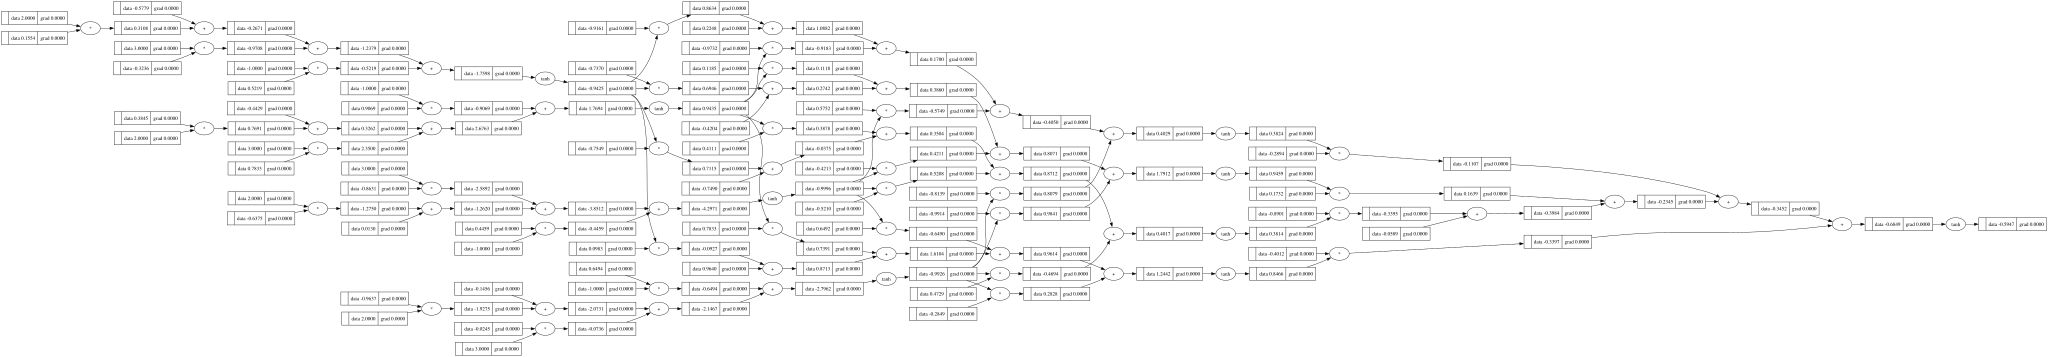

In [158]:
draw_dot(n(x))
# We are now able to create MLP's like below.

In [159]:
# Part 12: To create a small data set!

In [211]:
xs =[
[2.0, 3.0, -1.0],
[3.0, -1.0, 0.5],
[0.5, 1.0, 1.0],
[1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=0.3604757908185779),
 Value(data=-0.9115869965582878),
 Value(data=0.7595016396153769),
 Value(data=0.1060088292032757)]

In [209]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
# this calculates loss
# Now we want to minimise the loss - that would mean the better predictions we have made and our neural net is better.

loss

Value(data=4.311874306578405)

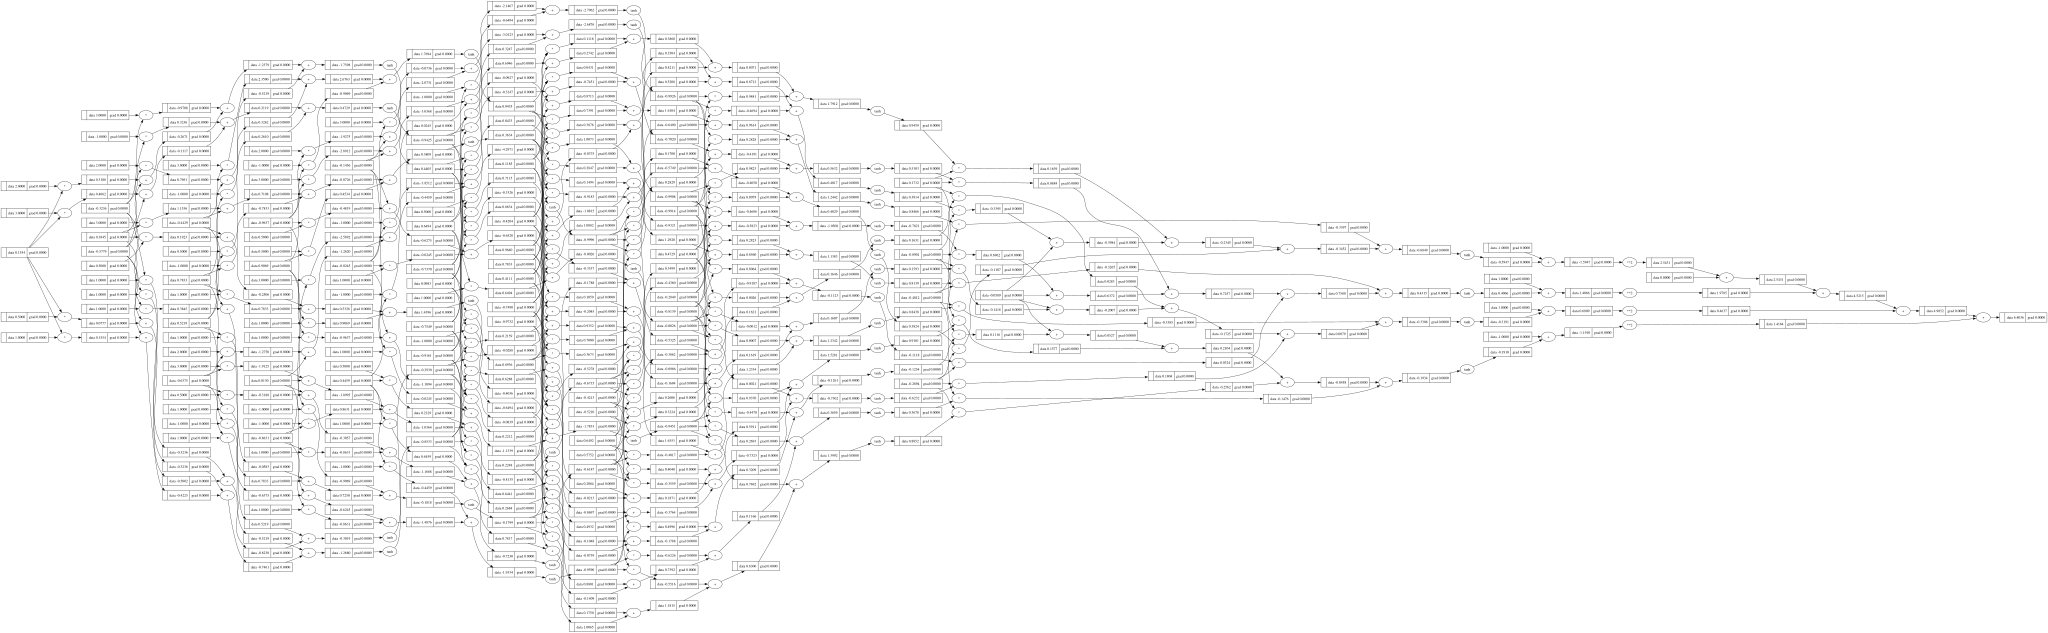

In [186]:
draw_dot(loss)

In [187]:
# Part 13: collecting all the parameters of the neural net.

In [210]:
for p in n.parameters():
    p.value += -0.01 * p.grad # minimizing loss, using gradient vector

In [ ]:
#gradient pass - repeatedly doing forward pass, backward pass and update.
# (do it on the above dataset later!)

# And that was my homebuilt Micrograd!!!!!!!!!!!!

"Micrograd is a tiny autograd engine (built by Andrej Karpathy) that implements backpropagation over a dynamically built computation graph of scalar values, along with a small neural-network library built on top of it — designed to show, in a few hundred lines of Python, how the core machinery behind libraries like PyTorch actually works."

(Micrograd is a small, simplified version of PyTorch that Andrej Karpathy built to show how neural networks actually learn under the hood — it tracks every math operation on numbers, then automatically figures out how to adjust them to reduce error (that's backpropagation))
